### 🔍 CELL 1: Import Library & Setup


In [1]:
# ─────────────────────────────────────────────
import os, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ Library loaded!")


# ─────────────────────────────────────────────

✅ Library loaded!


### 🔍 CELL 2: Konfigurasi Path & Model


In [2]:
# ─────────────────────────────────────────────
if os.name == 'posix':
    BASE_DIR = '/mnt/d/Antigravity/Visual Based Rekomender Sistem'
else:
    BASE_DIR = r'D:\Antigravity\Visual Based Rekomender Sistem'

FULL_CSV = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')
if not os.path.exists(FULL_CSV):
    FULL_CSV = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'data preperation', 'dataset_output', 'full_dataset.csv')

IMG_DIR  = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')
FEAT_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'partial unfreeze', 'fitur_vektor', 'retrieval_baru')
EVAL_DIR = os.path.join(BASE_DIR, 'skripsi', 'persiapan_skripsi', 'partial unfreeze', 'hasil_evaluasi')

os.makedirs(EVAL_DIR, exist_ok=True)

MODEL_NAMES = ['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3']
K_VALUES    = [1, 5, 10, 20, 50]

print("✅ Path configuration loaded!")
print(f"📁 Fitur dibaca dari : {FEAT_DIR}")
print(f"📁 Hasil disimpan di : {EVAL_DIR}")


# ─────────────────────────────────────────────

✅ Path configuration loaded!
📁 Fitur dibaca dari : D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\partial unfreeze\fitur_vektor\retrieval_baru
📁 Hasil disimpan di : D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\partial unfreeze\hasil_evaluasi


### 🔍 CELL 3: Load Metadata Query & Gallery


In [3]:
# ─────────────────────────────────────────────
print("\n📦 Memuat metadata dataset full_dataset.csv...")
df_full = pd.read_csv(FULL_CSV)

df_query   = df_full[df_full['split'] == 'query'].reset_index(drop=True)
df_gallery = df_full[df_full['split'] == 'gallery'].reset_index(drop=True)

print(f"📊 Total Query   : {len(df_query):,}")
print(f"📊 Total Gallery : {len(df_gallery):,}")


# ─────────────────────────────────────────────


📦 Memuat metadata dataset full_dataset.csv...
📊 Total Query   : 14,218
📊 Total Gallery : 12,612


### 🔍 CELL 4: Fungsi Evaluasi Retrieval (Recall@K & mAP)


In [4]:
# ─────────────────────────────────────────────
def evaluate_retrieval_batch(query_features, gallery_features, 
                             query_item_ids, gallery_item_ids, 
                             query_categories, k_values=[1, 5, 10, 20, 50]):
    """
    Menghitung Recall@K, mAP, dan Recall@5 per kategori pakaian.
    Memproses similarity matrix secara berjarak (batch) untuk hemat RAM.
    """
    n_queries = len(query_features)
    recall_at_k = {k: 0 for k in k_values}
    average_precisions = []
    
    # Tracking Recall@5 per Kategori
    category_recall5 = {}
    category_counts  = {}

    batch_size = 500 # Proses 500 query per batch
    
    for start in tqdm(range(0, n_queries, batch_size), desc="Calculating Cosine Similarity & Recall@K"):
        end = min(start + batch_size, n_queries)
        q_batch = query_features[start:end]
        
        # Cosine Similarity (Dot product dari vektor L2-normalized)
        sim_batch = q_batch @ gallery_features.T
        
        for idx in range(end - start):
            i = start + idx
            query_id  = query_item_ids[i]
            cat_label = query_categories[i]
            
            # Ground truth: gallery indices yang memiliki item_id yang sama
            gt_mask = (gallery_item_ids == query_id)
            n_relevant = gt_mask.sum()
            
            if n_relevant == 0:
                continue # Skip jika tidak ada pasangan di gallery
                
            sorted_indices = np.argsort(-sim_batch[idx])
            
            # Recall@K
            has_hit_k5 = False
            for k in k_values:
                top_k_ids = gallery_item_ids[sorted_indices[:k]]
                if query_id in top_k_ids:
                    recall_at_k[k] += 1
                    if k == 5:
                        has_hit_k5 = True
                        
            # Accumulate per Category for Recall@5
            if cat_label not in category_recall5:
                category_recall5[cat_label] = 0
                category_counts[cat_label]  = 0
            category_counts[cat_label] += 1
            if has_hit_k5:
                category_recall5[cat_label] += 1

            # mAP Calculation
            ap = 0.0
            n_correct = 0
            for rank, g_idx in enumerate(sorted_indices):
                if gt_mask[g_idx]:
                    n_correct += 1
                    ap += n_correct / (rank + 1)
            ap /= n_relevant
            average_precisions.append(ap)

    n_eval = len(average_precisions)
    
    summary_results = {}
    for k in k_values:
        summary_results[f'Recall@{k}'] = (recall_at_k[k] / n_eval * 100) if n_eval > 0 else 0.0
        
    summary_results['mAP'] = (np.mean(average_precisions) * 100) if n_eval > 0 else 0.0
    summary_results['n_queries'] = n_eval
    
    # Category Recall@5 breakdown (%)
    cat_summary = {}
    for cat, total in category_counts.items():
        cat_summary[cat] = (category_recall5[cat] / total * 100) if total > 0 else 0.0
        
    return summary_results, cat_summary


# ─────────────────────────────────────────────

### 🔍 CELL 5: Evaluasi Semua Model Partial Unfreeze (Exp 3)


In [5]:
# ─────────────────────────────────────────────
print("\n" + "="*65)
print("  🚀 EVALUASI RETRIEVAL (PARTIAL UNFREEZE)")
print("="*65)

overall_metrics = []
category_metrics = []

for model_name in MODEL_NAMES:
    print(f"\n🧠 Evaluasi Model: {model_name.upper()}")
    
    q_feat_path = os.path.join(FEAT_DIR, f'{model_name}_query_features.npy')
    g_feat_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_features.npy')
    q_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_query_valid_idx.npy')
    g_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_gallery_valid_idx.npy')
    
    if not (os.path.exists(q_feat_path) and os.path.exists(g_feat_path)):
        print(f"  ⚠️ Warning: File fitur {model_name} tidak ditemukan di {FEAT_DIR}! Skipping...")
        continue
        
    q_feats = np.load(q_feat_path)
    g_feats = np.load(g_feat_path)
    q_valid = np.load(q_idx_path)
    g_valid = np.load(g_idx_path)
    
    q_item_ids   = df_query.iloc[q_valid]['item_id'].values
    g_item_ids   = df_gallery.iloc[g_valid]['item_id'].values
    q_categories = df_query.iloc[q_valid]['category'].values
    
    print(f"  📌 Query Matrix   : {q_feats.shape}")
    print(f"  📌 Gallery Matrix : {g_feats.shape}")
    
    summary, cat_summary = evaluate_retrieval_batch(
        q_feats, g_feats, q_item_ids, g_item_ids, q_categories, K_VALUES
    )
    
    row_summary = {'model': model_name.upper(), **summary}
    overall_metrics.append(row_summary)
    
    for cat, r5 in cat_summary.items():
        category_metrics.append({
            'model': model_name.upper(),
            'category': cat,
            'Recall@5': r5
        })
        
    print(f"  ✅ Recall@1 : {summary['Recall@1']:.2f}%")
    print(f"  ✅ Recall@5 : {summary['Recall@5']:.2f}%")
    print(f"  ✅ Recall@10: {summary['Recall@10']:.2f}%")
    print(f"  ✅ Recall@20: {summary['Recall@20']:.2f}%")
    print(f"  ✅ Recall@50: {summary['Recall@50']:.2f}%")
    print(f"  ✅ mAP      : {summary['mAP']:.2f}%")
    
    del q_feats, g_feats
    gc.collect()


# ─────────────────────────────────────────────


  🚀 EVALUASI RETRIEVAL (PARTIAL UNFREEZE)

🧠 Evaluasi Model: RESNET50
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.12s/it]


  ✅ Recall@1 : 32.42%
  ✅ Recall@5 : 52.24%
  ✅ Recall@10: 59.97%
  ✅ Recall@20: 67.76%
  ✅ Recall@50: 76.99%
  ✅ mAP      : 19.01%

🧠 Evaluasi Model: VGG19
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.12s/it]


  ✅ Recall@1 : 32.92%
  ✅ Recall@5 : 52.23%
  ✅ Recall@10: 60.59%
  ✅ Recall@20: 68.59%
  ✅ Recall@50: 77.68%
  ✅ mAP      : 19.48%

🧠 Evaluasi Model: INCEPTIONV3
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.12s/it]


  ✅ Recall@1 : 25.06%
  ✅ Recall@5 : 42.97%
  ✅ Recall@10: 51.29%
  ✅ Recall@20: 59.48%
  ✅ Recall@50: 70.52%
  ✅ mAP      : 14.25%

🧠 Evaluasi Model: MOBILENETV3
  📌 Query Matrix   : (14218, 512)
  📌 Gallery Matrix : (12612, 512)


Calculating Cosine Similarity & Recall@K: 100%|██████████| 29/29 [00:32<00:00,  1.11s/it]

  ✅ Recall@1 : 38.87%
  ✅ Recall@5 : 59.62%
  ✅ Recall@10: 67.71%
  ✅ Recall@20: 74.68%
  ✅ Recall@50: 82.94%
  ✅ mAP      : 23.75%


### 🔍 CELL 6: Simpan Laporan Evaluasi & Visualisasi



  📊 SUMMARY HASIL RETRIEVAL (PARTIAL UNFREEZE)
      model  Recall@1  Recall@5  Recall@10  Recall@20  Recall@50       mAP  n_queries
   RESNET50 32.416655 52.236601  59.966240  67.759179  76.986918 19.013266      14218
      VGG19 32.923055 52.229568  60.592207  68.589112  77.683218 19.483572      14218
INCEPTIONV3 25.059783 42.966662  51.287101  59.480940  70.516247 14.245841      14218
MOBILENETV3 38.866226 59.621606  67.709945  74.679983  82.937122 23.747908      14218

💾 Tabel hasil overall disimpan di:
  D:\Antigravity\Visual Based Rekomender Sistem\skripsi\persiapan_skripsi\partial unfreeze\hasil_evaluasi\partial_unfreeze_retrieval_overall_results.csv



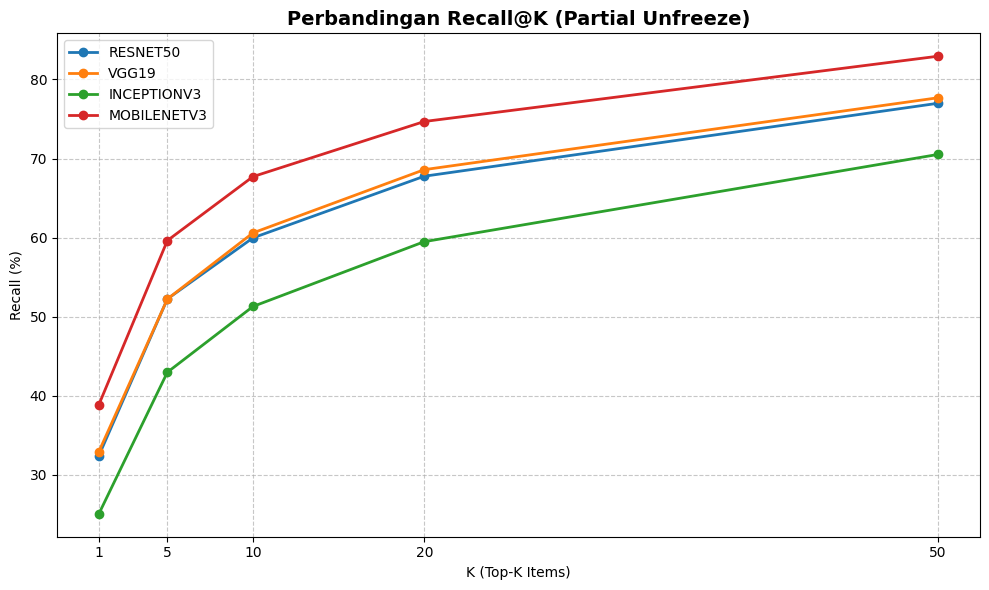

In [6]:
# ─────────────────────────────────────────────
# CELL 6: Simpan Laporan CSV Overall & Plot Line Chart Recall@K
# ─────────────────────────────────────────────
if overall_metrics:
    df_results = pd.DataFrame(overall_metrics)
    csv_path = os.path.join(EVAL_DIR, 'partial_unfreeze_retrieval_overall_results.csv')
    df_results.to_csv(csv_path, index=False)
    
    print("\n=================================================================")
    print("  📊 SUMMARY HASIL RETRIEVAL (PARTIAL UNFREEZE)")
    print("=================================================================")
    print(df_results.to_string(index=False))
    print("=================================================================")
    print(f"\n💾 Tabel hasil overall disimpan di:\n  {csv_path}\n")
    
    # Plot Line Chart Perbandingan Recall@K (Inline Only)
    plt.figure(figsize=(10, 6))
    for res in overall_metrics:
        m_name = res['model']
        r_vals = [res[f'Recall@{k}'] for k in K_VALUES]
        plt.plot(K_VALUES, r_vals, marker='o', linewidth=2, label=m_name)
        
    plt.title('Perbandingan Recall@K (Partial Unfreeze)', fontsize=14, fontweight='bold')
    plt.xlabel('K (Top-K Items)')
    plt.ylabel('Recall (%)')
    plt.xticks(K_VALUES)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("\n⚠️ Tidak ada fitur model yang dievaluasi.")


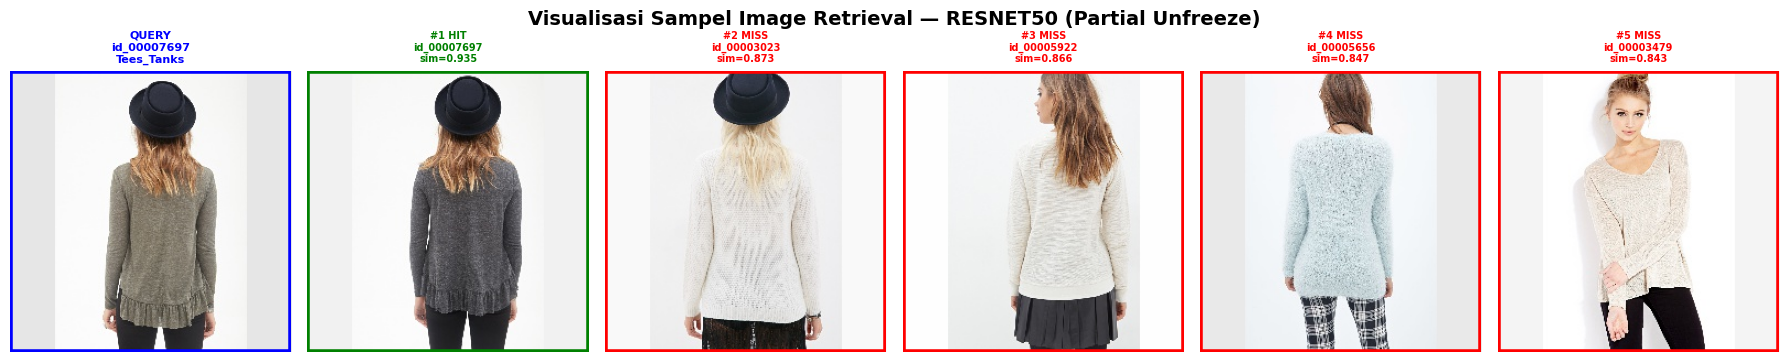

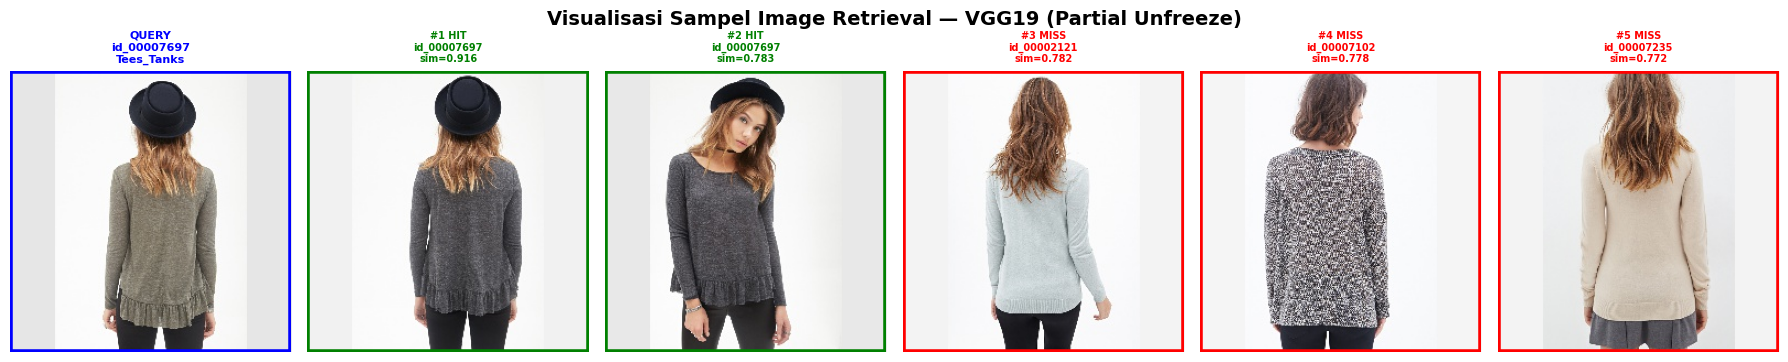

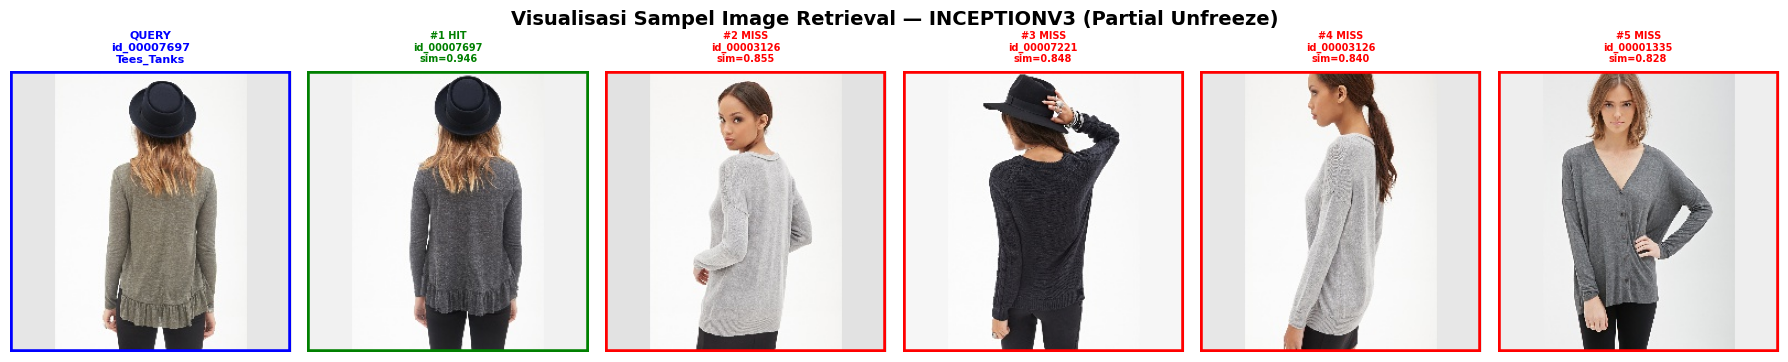

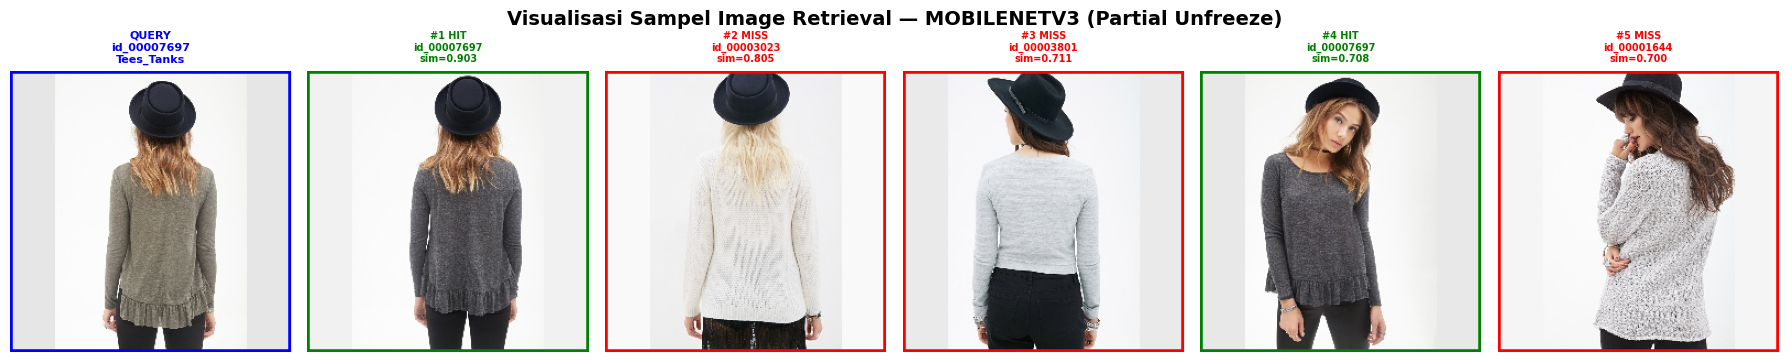

In [7]:
# ─────────────────────────────────────────────
# CELL 7: Visualisasi Sampel Image Retrieval (Fix Path Gambar Lokal)
# ─────────────────────────────────────────────
import matplotlib.patches as patches
from PIL import Image

def get_local_img_path(image_name):
    """Mengonversi image_name menjadi path file lokal yang valid."""
    img_str = str(image_name)
    if img_str.startswith('img/'):
        img_str = img_str.replace('img/', '', 1)
    return os.path.join(IMG_DIR, os.path.normpath(img_str))

def visualize_sample_retrieval_partial(model_name, df_query, df_gallery, n_samples=3, top_k=5, seed=99):
    """
    Menampilkan visualisasi sampel pencarian retrieval (Query vs Top-K Gallery)
    untuk model tertentu pada Partial Unfreeze. Gambar hanya ditampilkan di notebook.
    """
    q_feat_path = os.path.join(FEAT_DIR, f'{model_name}_query_features.npy')
    g_feat_path = os.path.join(FEAT_DIR, f'{model_name}_gallery_features.npy')
    q_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_query_valid_idx.npy')
    g_idx_path  = os.path.join(FEAT_DIR, f'{model_name}_gallery_valid_idx.npy')
    
    if not (os.path.exists(q_feat_path) and os.path.exists(g_feat_path)):
        print(f"⚠️ File fitur untuk model {model_name} tidak ditemukan.")
        return

    q_feats = np.load(q_feat_path)
    g_feats = np.load(g_feat_path)
    q_valid = np.load(q_idx_path)
    g_valid = np.load(g_idx_path)
    
    df_q_sub = df_query.iloc[q_valid].reset_index(drop=True)
    df_g_sub = df_gallery.iloc[g_valid].reset_index(drop=True)
    
    q_item_ids = df_q_sub['item_id'].values
    g_item_ids = df_g_sub['item_id'].values

    # L2 Normalization
    q_norms = np.linalg.norm(q_feats, axis=1, keepdims=True)
    g_norms = np.linalg.norm(g_feats, axis=1, keepdims=True)
    q_norms[q_norms == 0] = 1.0
    g_norms[g_norms == 0] = 1.0
    q_feats = q_feats / q_norms
    g_feats = g_feats / g_norms

    # Pilih sampel query secara acak
    rng = np.random.default_rng(seed)
    sample_q_indices = rng.choice(len(df_q_sub), size=n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, top_k + 1, figsize=(3 * (top_k + 1), 3.5 * n_samples))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    fig.suptitle(f'Visualisasi Sampel Image Retrieval — {model_name.upper()} (Partial Unfreeze)', fontsize=14, fontweight='bold', y=1.02)

    for row, q_idx in enumerate(sample_q_indices):
        query_row = df_q_sub.iloc[q_idx]
        query_id = query_row['item_id']
        query_vec = q_feats[q_idx]

        # Tampilkan Query Image dari Path Lokal
        ax_q = axes[row, 0]
        q_img_path = get_local_img_path(query_row['image_name'])
        try:
            img = Image.open(q_img_path).convert('RGB')
            ax_q.imshow(img)
        except Exception:
            ax_q.text(0.5, 0.5, 'Image Error', ha='center', va='center')
        
        q_cat = str(query_row.get('category', ''))
        ax_q.set_title(f"QUERY\n{query_id}\n{q_cat}", fontsize=8, color='blue', fontweight='bold')
        ax_q.axis('off')
        rect = patches.Rectangle((0, 0), 1, 1, transform=ax_q.transAxes, linewidth=4, edgecolor='blue', facecolor='none')
        ax_q.add_patch(rect)

        # Hitung Similarity ke seluruh Gallery
        sim_scores = g_feats @ query_vec
        sorted_g_idx = np.argsort(-sim_scores)[:top_k]

        # Tampilkan Top-K Gallery dari Path Lokal
        for col, g_rank_idx in enumerate(sorted_g_idx):
            ax_g = axes[row, col + 1]
            gallery_row = df_g_sub.iloc[g_rank_idx]
            gallery_id = gallery_row['item_id']
            sim_score = sim_scores[g_rank_idx]
            is_hit = (gallery_id == query_id)

            g_img_path = get_local_img_path(gallery_row['image_name'])
            try:
                img = Image.open(g_img_path).convert('RGB')
                ax_g.imshow(img)
            except Exception:
                ax_g.text(0.5, 0.5, 'Image Error', ha='center', va='center')

            status = "HIT" if is_hit else "MISS"
            color = 'green' if is_hit else 'red'
            ax_g.set_title(f"#{col+1} {status}\n{gallery_id}\nsim={sim_score:.3f}", fontsize=7, color=color, fontweight='bold')
            ax_g.axis('off')
            rect = patches.Rectangle((0, 0), 1, 1, transform=ax_g.transAxes, linewidth=4, edgecolor=color, facecolor='none')
            ax_g.add_patch(rect)

    plt.tight_layout()
    vis_out = os.path.join(EVAL_DIR, f'retrieval_visual_{model_name}_partial_unfreeze.png')
    # plt.savefig(vis_out, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# Jalankan visualisasi sampel untuk tiap model
for m_name in ['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3']:
    visualize_sample_retrieval_partial(m_name, df_query, df_gallery, n_samples=1, top_k=5)


  📊 TABEL RECALL@5 PER KATEGORI PAKAIAN (PARTIAL UNFREEZE)
model                INCEPTIONV3  MOBILENETV3  RESNET50  VGG19
category                                                      
Blouses_Shirts             32.23        54.11     43.74  43.94
Cardigans                  38.44        59.80     47.74  48.74
Denim                      41.36        50.26     46.60  45.03
Dresses                    47.19        66.07     57.86  59.44
Graphic_Tees               13.97        28.77     24.11  21.92
Jackets_Coats              34.31        51.93     41.83  42.75
Jackets_Vests              56.67        66.67     64.44  66.67
Leggings                   48.53        61.76     60.29  63.24
Pants                      53.62        61.72     60.98  63.31
Rompers_Jumpsuits          47.74        65.02     60.70  59.05
Shirts_Polos               47.25        64.68     58.72  55.96
Shorts                     45.16        58.37     54.36  54.68
Skirts                     64.01        77.20     67.75  74

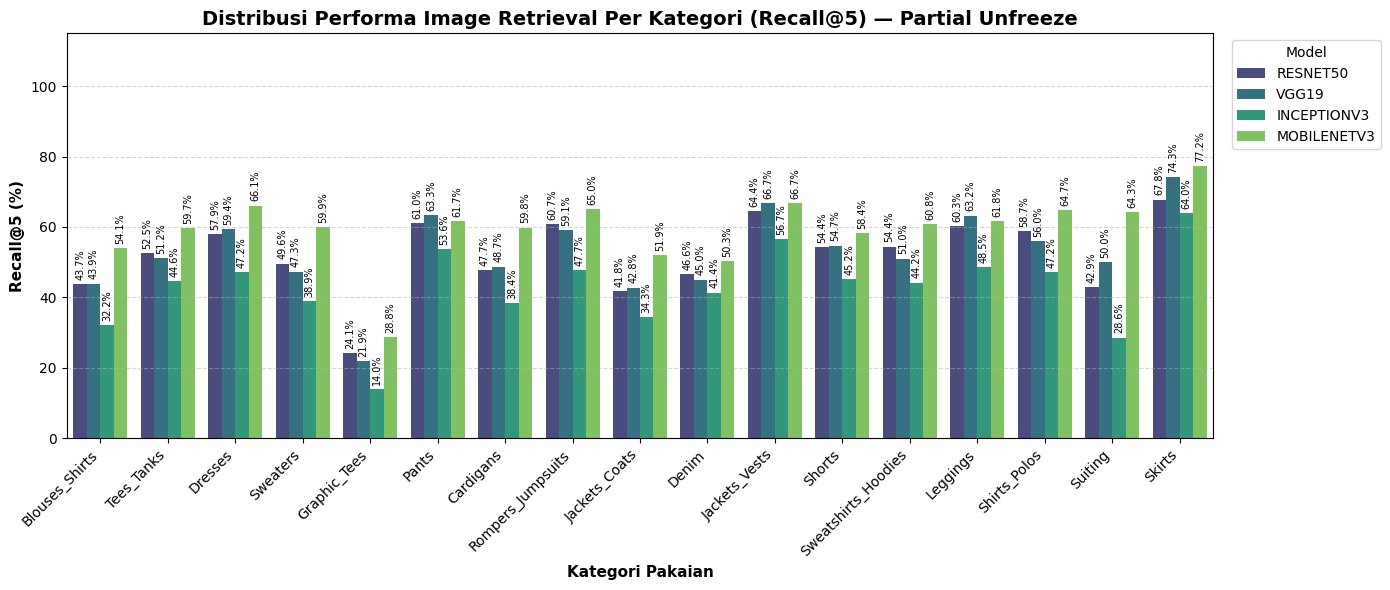

In [8]:
# ─────────────────────────────────────────────
# CELL 8: Grafik & Ekspor CSV Distribusi Retrieval Per Kategori (Recall@5)
# ─────────────────────────────────────────────
if 'category_metrics' in locals() and category_metrics:
    df_cat = pd.DataFrame(category_metrics)
    
    # 1. Simpan Hasil ke File CSV
    csv_cat_path = os.path.join(EVAL_DIR, 'retrieval_category_evaluation_partial_unfreeze.csv')
    
    # Format pivot table (Kategori sebagai baris, Model sebagai kolom)
    df_pivot = df_cat.pivot(index='category', columns='model', values='Recall@5').round(2)
    df_pivot.to_csv(csv_cat_path)
    
    print("=================================================================")
    print("  📊 TABEL RECALL@5 PER KATEGORI PAKAIAN (PARTIAL UNFREEZE)")
    print("=================================================================")
    print(df_pivot.to_string())
    print("=================================================================")
    print(f"\n💾 File CSV per kategori tersimpan di:\n  {csv_cat_path}\n")
    
    # 2. Plot Grouped Bar Chart (Inline Only)
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        data=df_cat, 
        x='category', 
        y='Recall@5', 
        hue='model', 
        palette='viridis'
    )
    
    plt.title('Distribusi Performa Image Retrieval Per Kategori (Recall@5) — Partial Unfreeze', fontsize=14, fontweight='bold')
    plt.xlabel('Kategori Pakaian', fontsize=11, fontweight='bold')
    plt.ylabel('Recall@5 (%)', fontsize=11, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 115)
    plt.grid(True, linestyle='--', alpha=0.5, axis='y')
    plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    
    # Label angka di atas batang
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', 
                fontsize=7, 
                rotation=90, 
                xytext=(0, 3), 
                textcoords='offset points'
            )
            
    plt.tight_layout()
    plt.show()
    plt.close()
else:
    print("⚠️ Data category_metrics belum tersedia. Pastikan Cell 5 sudah dijalankan terlebih dahulu.")
